# Channel Noise Estimation - Data Exploration

This notebook explores the generated synthetic dataset used for SNR prediction.

Objectives:

1. Load dataset
2. Verify shapes
3. Check SNR label distribution
4. Visualize noisy signals
5. Compare spectrograms at different SNR levels

## Import libraries

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

## create figures dictionary

In [6]:
os.makedirs("figures",exist_ok=True)
print("figures directory ready")

figures directory ready


## load dataset

In [10]:
X_raw = np.load(
    r"C:\Users\suhan\OneDrive\Desktop\channel noise estimator\data\X_raw.npy"
)
y = np.load(
    r"C:\Users\suhan\OneDrive\Desktop\channel noise estimator\data\y_snr.npy"
)

## verify dataset

In [11]:
print("X_raw shape", X_raw.shape)
print("y Shape:", y.shape)
print("Total Samples:", len(X_raw))

X_raw shape (21000, 512)
y Shape: (21000,)
Total Samples: 21000


## SNR label distribution

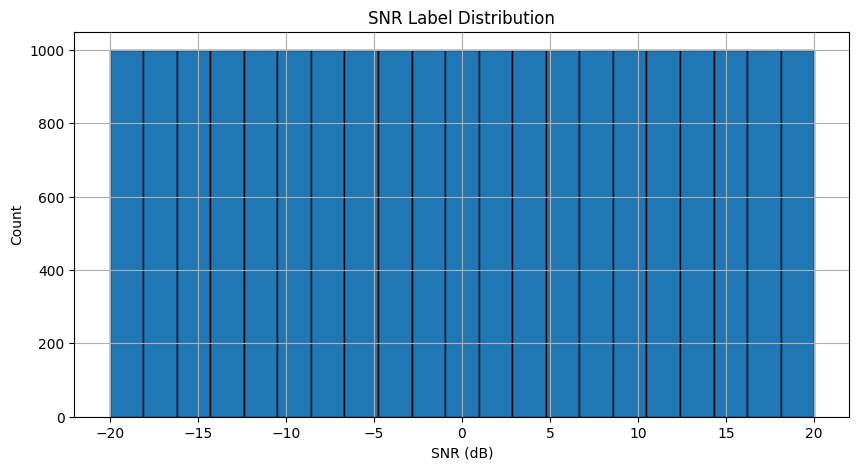

In [12]:
plt.figure(figsize=(10,5))
plt.hist(
    y,
    bins=21,
    edgecolor="black"
)
plt.title("SNR Label Distribution")
plt.xlabel("SNR (dB)")
plt.ylabel("Count")
plt.grid(True)
plt.savefig(
    "figures/snr_distribution.png",
    bbox_inches="tight"
)
plt.show()

### Observation

The histogram confirms that all SNR levels are equally represented.

This balanced distribution prevents bias during regression model training.

## Signal Visualization at Different SNR Levels

In [13]:
snr_examples = [
    20,
    10,
    0,
    -10,
    -20
]

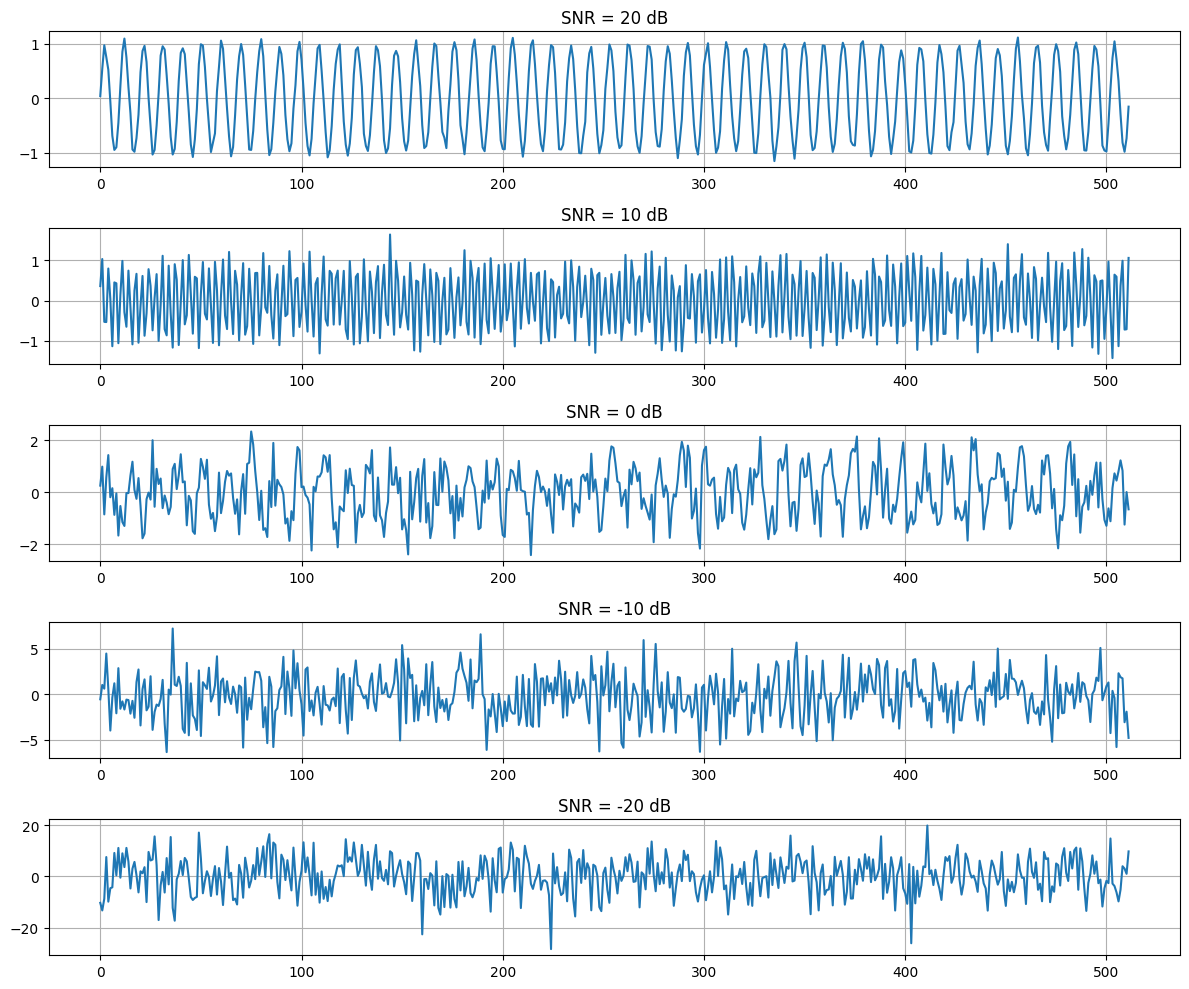

In [17]:
plt.figure(figsize=(12,10))
for i, snr in enumerate(snr_examples):

    idx = np.where(
        y == snr
    )[0][0]

    signal = X_raw[idx]

    plt.subplot(
        5,
        1,
        i + 1
    )

    plt.plot(signal)

    plt.title(
        f"SNR = {snr} dB"
    )

    plt.grid(True)

plt.tight_layout()

plt.savefig(
    "figures/example_signals.png",
    bbox_inches="tight"
)

plt.show()

### Observation

As SNR decreases, the signal becomes progressively harder to distinguish from noise.

At -20 dB the waveform is almost completely buried.

## Spectrogram Analysis

In [18]:
high_idx = np.where(
    y == 20
)[0][0]

low_idx = np.where(
    y == -20
)[0][0]

In [19]:
high_signal = X_raw[high_idx]

low_signal = X_raw[low_idx]

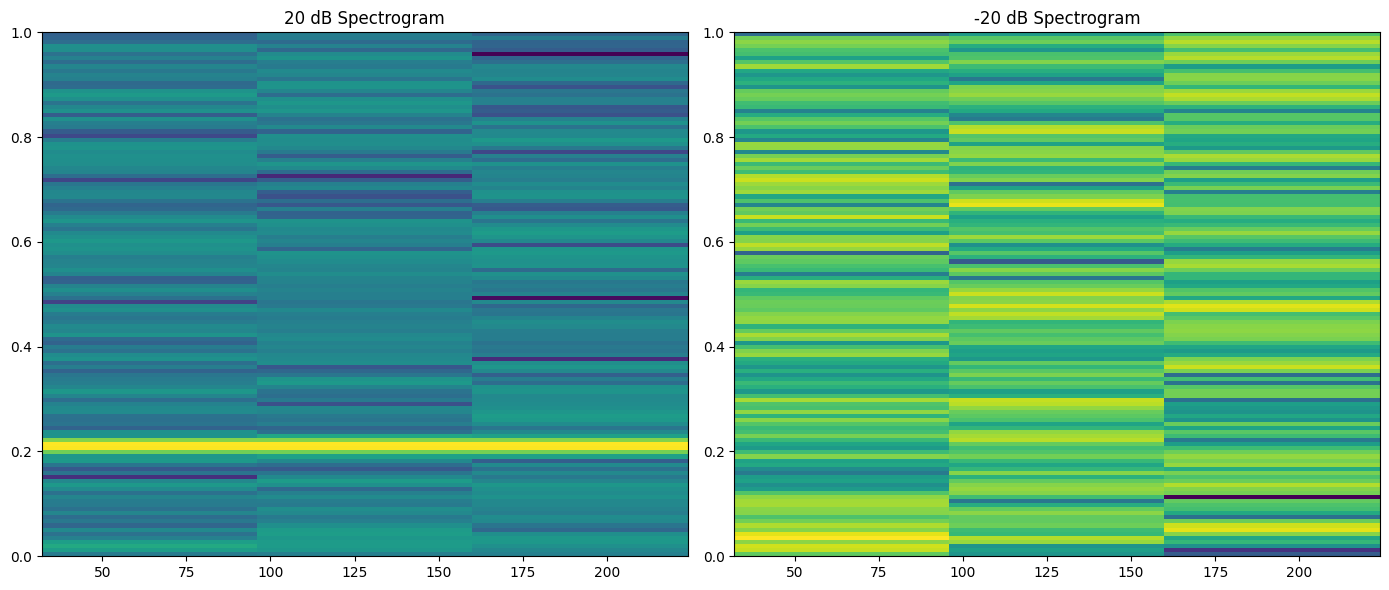

In [20]:
plt.figure(figsize=(14,6))

plt.subplot(1,2,1)

plt.specgram(high_signal)

plt.title("20 dB Spectrogram")

plt.subplot(1,2,2)

plt.specgram(low_signal)

plt.title("-20 dB Spectrogram")

plt.tight_layout()

plt.savefig(
    "figures/spectrogram_comparison.png",
    bbox_inches="tight"
)

plt.show()

### Observation

The high-SNR signal retains clear spectral structure.

At low SNR, noise spreads energy across many frequencies, making the underlying signal difficult to identify.

# Summary

Key Findings:

- Dataset contains 21,000 noisy signals.
- SNR labels are evenly distributed from -20 dB to +20 dB.
- Signal quality visibly degrades as SNR decreases.
- Spectrograms reveal increasing frequency-domain corruption at lower SNR values.

The dataset appears balanced and suitable for feature extraction and regression model training.